# LSZ Spectroscopy — main driver notebook

All physics, Fourier analysis, spectrum reconstruction, and state-vector validation live in `src/`. This notebook only wires them together.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('/Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/lsz_spectroscopy/src')

from lsz_experiment import LSZ_experiment, run_experiment_sweep
from diagnostics import run_full_diagnostics

## Parameters

In [2]:
epsilon = 1
alpha = 1
ramp_time = 0.75
n_steps = 201
dt = 0.05
r_noise = False
w_noise = True

# 2 qubit example (GHz)
local_z_list = np.array([2.1, 1.1])
zz_terms = np.array([0.35])

t1_rates = [0.015, 0.02]
#t1_rates = [1e-12, 1e-12]
t2_rates = [0.01, 0.015]
#t1_rates = [1e-12, 1e-12]

#3 qubit example
# local_z_list = np.array([2.1, 3.05, 1.78])
# zz_terms = np.array([1.22, 0.54, 0.3])

# t1_rates = [0.005, 0.0051, 0.0048]
# t2_rates = [0.01, 0.012, 0.0098]

nqubits = len(local_z_list)
max_wait_time = 50.0/alpha
n_sims = int(max_wait_time*20)

tw_l = np.linspace(0, max_wait_time, n_sims)

H_target_dict = {'one_body': local_z_list, 'two_body': zz_terms}

print('Max wait time:', max_wait_time)
print('dt:', dt)
print('Number of simulations:', n_sims)

Max wait time: 50.0
dt: 0.05
Number of simulations: 1000


## Schedule and spectrum preview

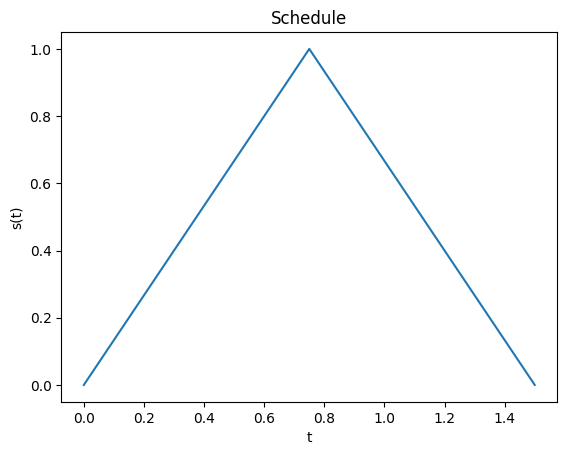

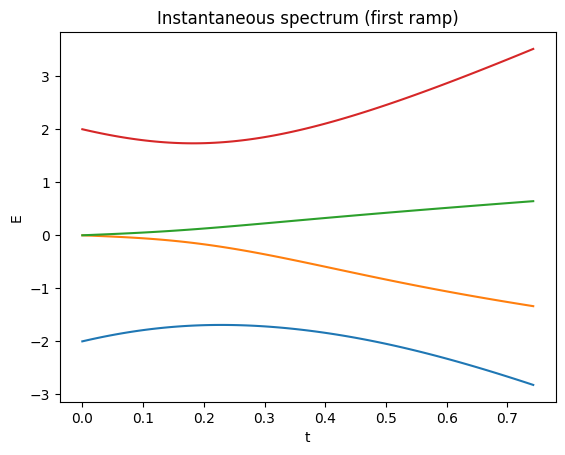

Spectrum at midpoint: [-2.85 -1.35  0.65  3.55]


In [3]:
preview = LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, 0, dt)

t_list, s_list = preview.show_schedule(n_steps)
plt.plot(t_list, s_list)
plt.xlabel('t'); plt.ylabel('s(t)'); plt.title('Schedule')
plt.show()

t_list, egvals, egvecs = preview.show_spectrum(n_steps)
midpoint = int(len(t_list)/2)
plt.plot(t_list[0:midpoint], egvals[0:midpoint])
plt.xlabel('t'); plt.ylabel('E'); plt.title('Instantaneous spectrum (first ramp)')
plt.show()

egvals_midpoint = egvals[midpoint]
print('Spectrum at midpoint:', egvals_midpoint)

## Run the experiment sweep

In [4]:
pc_list = run_experiment_sweep(
    nqubits, epsilon, H_target_dict, ramp_time, tw_l, dt,
    r_noise=r_noise, w_noise=w_noise,
    gamma_dec_list=t1_rates, gamma_dep_list=t2_rates,
)

## Full diagnostics

Fourier analysis + global fit + energy-difference matching + turnpike reconstruction + u_m / phi_m recovery + exact-state validation + (optional) dephasing comparison.

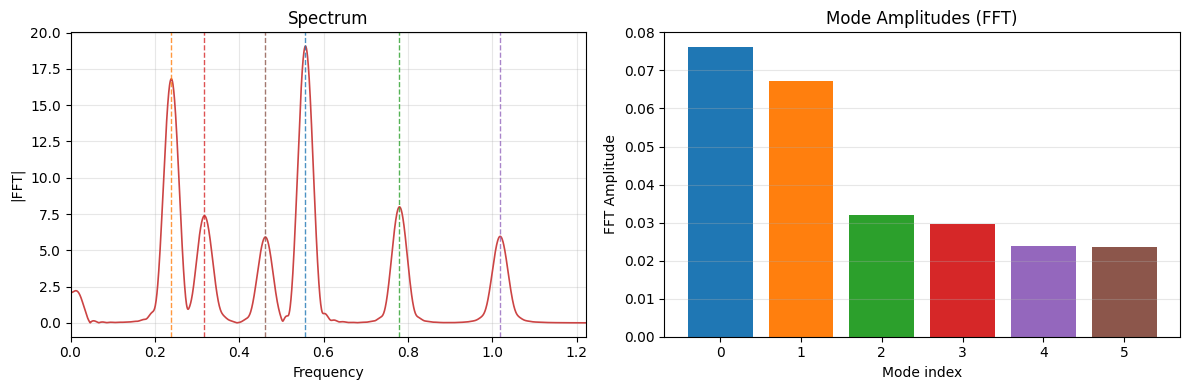


  #       Frequency   Phase (rad)
-----------------------------------
  1        0.556964        2.6520
  2        0.238963        1.0994
  3        0.779856        3.6134
  4        0.317541        1.5470
  5        1.018589        4.8096
  6        0.461935        2.0725


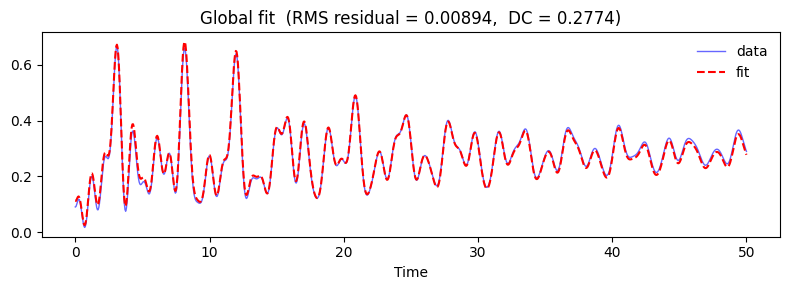

Amplitudes: [0.07478096 0.0892468  0.04804443 0.07125856 0.05295527 0.04288624]
Decay rates: [0.02808734 0.04166107 0.04776528 0.07217657 0.06658413 0.05727514]
DC (fitted): 0.2774452859413703   DC (mean): 0.27385297723993235

                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        3.499510        3.500000       -0.000490          -0.014%
   2        1.501450        1.500000       +0.001450          +0.097%
   3        4.899981        4.900000       -0.000019          -0.000%
   4        1.995171        2.000000       -0.004829          -0.241%
   5        6.399984        6.400000       -0.000016          -0.000%
   6        2.902424        2.900000       +0.002424          +0.084%
--------------------------------------------------------------------
        

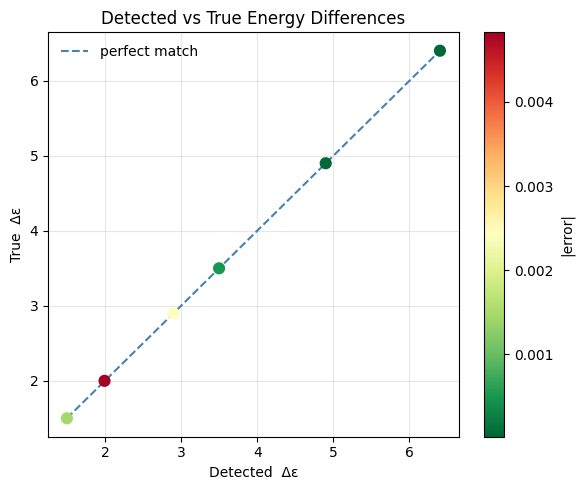

Incomplete Turnpike Solver
  Target levels:        4
  Expected differences: 6
  Observed differences: 6 (100%)

  Trying match threshold = 100% ... found solution explaining 6/6 (100%) of observations.

  Running greedy solver for comparison...
  Greedy explains 6/6 (100%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(1.5), np.float64(3.4995), np.float64(6.4)]
    Explains 6/6 observed differences (100%)

                  E0      E1      E2      E3
True:         0.0000  1.5000  3.5000  6.4000
Forward:      0.0000  1.5000  3.4995  6.4000  <-- best
Reversed:     0.0000  2.9005  4.9000  6.4000


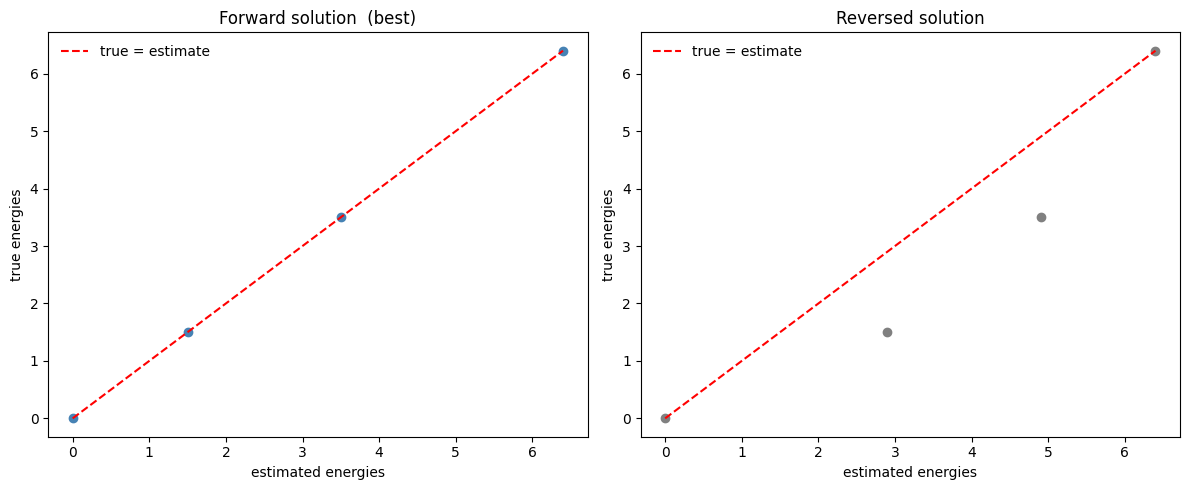

e_m:   [0.     1.5015 3.4995 6.4   ]
phi_m: [0.     2.5919 1.8156 0.7368]
u_m:   [0.5532 0.5334 0.4961 0.4124]
Exact |u_m|: [0.55638587 0.52726855 0.48863342 0.41672535]
Exact phases (mod pi, rel to u_0): [0.         2.56495554 1.828654   0.7515675 ]


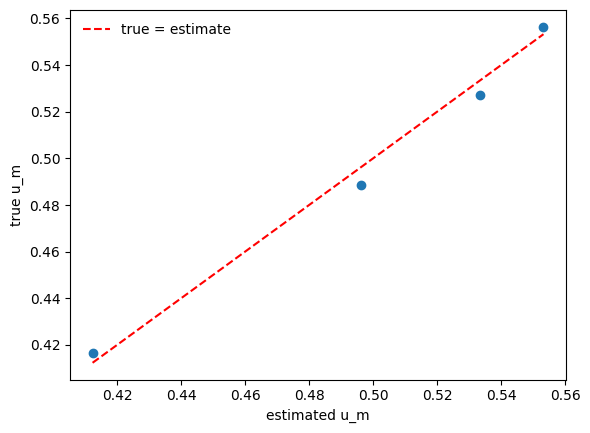

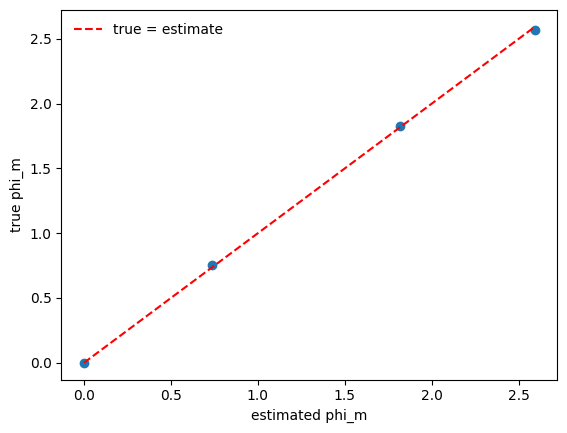

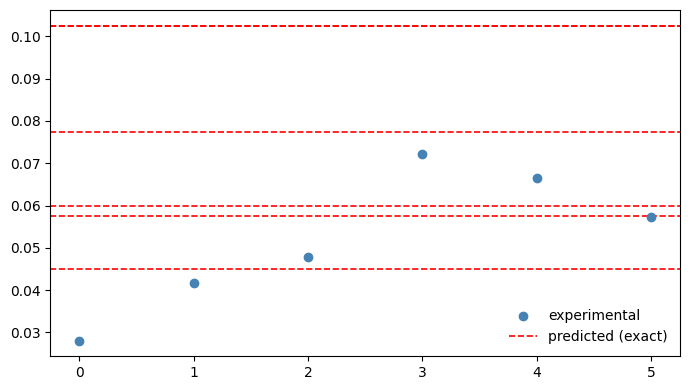

Possible lambdas (upper bound): [0.045000035000035, 0.05750007500075001, 0.10250011000078502, 0.10250011000078502, 0.07750007500075001, 0.06000018500153501]
Experimental lambdas: [0.02808734 0.04166107 0.04776528 0.07217657 0.06658413 0.05727514]


In [5]:
results = run_full_diagnostics(
    pc_list, tw_l, nqubits, epsilon, H_target_dict,
    ramp_time, dt, egvals_midpoint,
    w_noise=w_noise,
    t2_rates=t2_rates if w_noise else None,
)

In [6]:
"""
Forward calculation of coherence decay rates Gamma_{mn} from per-qubit
T1 and T2_phi (pure dephasing) times.

This is the inverse companion to extract_rates.py: given the underlying
per-qubit decoherence parameters, predict what coherence decay rates one
should observe in the LZS signal. Useful for:

  - Validating the structural formula before fitting real data.
  - Generating synthetic test data for the rate-extraction pipeline.
  - Sanity-checking extracted rates by re-predicting and comparing
    to observed Gamma_{mn}.

The formula being implemented is:

    Gamma_{mn} = sum_q [ kappa_phi_q * d_q(m,n)
                        + (1/2) * kappa_T1_q * (e_q(m) + e_q(n)) ]

where, with the convention 0 -> |0> (z=+1), 1 -> |1> (z=-1):

    d_q(m,n) = 1 if qubits m,n disagree on bit q, else 0
    e_q(m)   = 1 if qubit q is excited (|1>) in state m, else 0

    kappa_phi_q = 1 / T2_phi_q   (pure dephasing rate of qubit q)
    kappa_T1_q  = 1 / T1_q       (amplitude damping rate of qubit q)
"""

import numpy as np
from itertools import combinations, product


def enumerate_bitstrings(N_q):
    """
    Enumerate all 2^N_q computational basis states as 0/1 bitstrings.
    Convention: leftmost bit = qubit 1 = most significant.

    Returns: (2^N_q, N_q) array, row m gives the bitstring of state |m>.
    """
    return np.array([[(m >> (N_q - 1 - q)) & 1 for q in range(N_q)]
                     for m in range(2 ** N_q)], dtype=int)


def predict_gamma_rates(T1_list, T2_phi_list, return_breakdown=False):
    """
    Predict coherence decay rates Gamma_{mn} for all pairs of computational
    basis states, given per-qubit T1 and pure-dephasing T2_phi times.

    Parameters
    ----------
    T1_list : array_like of length N_q
        Amplitude damping times for each qubit. Units: time (e.g. microseconds).
        Use np.inf for a qubit with no T1 decay.
    T2_phi_list : array_like of length N_q
        Pure dephasing times for each qubit (NOT total T2 -- this is the
        contribution beyond the T1-induced dephasing). Units: same as T1.
        Use np.inf for a qubit with no pure dephasing.
    return_breakdown : bool
        If True, also return separate dephasing and amplitude-damping
        contributions for diagnostic purposes.

    Returns
    -------
    Gamma : dict {(m, n): rate}
        Total coherence decay rate for each pair m < n.
        Keys are tuples of state indices, values are rates in 1/(time unit).
    breakdown : dict (only if return_breakdown=True)
        {'dephasing': {(m,n): rate}, 'amp_damping': {(m,n): rate}}
    """
    T1 = np.asarray(T1_list, dtype=float)
    T2_phi = np.asarray(T2_phi_list, dtype=float)
    if T1.shape != T2_phi.shape:
        raise ValueError("T1_list and T2_phi_list must have the same length")

    N_q = T1.size
    # Use safe inversion: 1/inf = 0, leaving qubits without that decay channel.
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)
    kappa_phi = np.where(np.isfinite(T2_phi) & (T2_phi > 0), 1.0 / T2_phi, 0.0)

    bitstrings = enumerate_bitstrings(N_q)  # shape (2^N_q, N_q)
    M = bitstrings.shape[0]

    Gamma = {}
    deph = {}
    amp = {}

    for m, n in combinations(range(M), 2):
        bm = bitstrings[m]
        bn = bitstrings[n]

        # Dephasing contribution: rate per qubit where the two states disagree.
        d = (bm != bn).astype(float)
        gamma_phi = float(np.sum(kappa_phi * d))

        # Amplitude damping contribution: rate per qubit, weighted by
        # (excited-in-m) + (excited-in-n), times 1/2.
        e_sum = bm.astype(float) + bn.astype(float)
        gamma_T1 = 0.5 * float(np.sum(kappa_T1 * e_sum))

        Gamma[(m, n)] = gamma_phi + gamma_T1
        deph[(m, n)] = gamma_phi
        amp[(m, n)] = gamma_T1

    if return_breakdown:
        return Gamma, {'dephasing': deph, 'amp_damping': amp}
    return Gamma


def predict_T1_eigenvalues(T1_list):
    """
    Predict the 2^N_q eigenvalues of the population Markov-chain rate matrix W
    under independent amplitude damping. These are the decay rates that
    appear in the zero-frequency Lorentzian fit.

    Each subset S of {1,...,N_q} contributes mu_S = sum_{q in S} kappa_T1_q.

    Parameters
    ----------
    T1_list : array_like of length N_q

    Returns
    -------
    eigenvalues : dict {frozenset(qubit indices): mu_S}
        The empty subset gives mu = 0 (steady state).
    """
    T1 = np.asarray(T1_list, dtype=float)
    N_q = T1.size
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)

    eigenvalues = {}
    for mask in range(2 ** N_q):
        S = frozenset(q for q in range(N_q) if (mask >> q) & 1)
        eigenvalues[S] = float(sum(kappa_T1[q] for q in S))
    return eigenvalues


# -----------------------------------------------------------------------------
# Validation against direct Lindblad simulation
# -----------------------------------------------------------------------------

def lindblad_decay_rates_numeric(T1_list, T2_phi_list):
    """
    Directly simulate the Lindblad dynamics for the dephasing-only sector of
    each coherence and extract the decay rate numerically. This bypasses the
    formula entirely and serves as ground truth for validation.

    For pure dephasing + amplitude damping with H = 0, each diagonal element
    of rho in the computational basis evolves as a Markov chain (T1 only),
    while each off-diagonal rho_{mn} satisfies:

        d/dt rho_{mn} = -Gamma_{mn} rho_{mn} + (T1 feed-in from descendants)

    For the purpose of extracting Gamma_{mn} alone, we set the descendant
    coherences to zero in the initial state and read off the initial decay
    rate of rho_{mn} from a short-time linear fit of -d/dt log|rho_{mn}|.

    Returns dict {(m,n): rate}.
    """
    T1 = np.asarray(T1_list, dtype=float)
    T2_phi = np.asarray(T2_phi_list, dtype=float)
    N_q = T1.size
    M = 2 ** N_q
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)
    kappa_phi = np.where(np.isfinite(T2_phi) & (T2_phi > 0), 1.0 / T2_phi, 0.0)

    bitstrings = enumerate_bitstrings(N_q)
    rates = {}

    # For each pair, evaluate d/dt rho_{mn} at t=0 with rho_{mn}(0) = 1
    # and all other entries = 0. This isolates the diagonal of the
    # Lindblad superoperator on that coherence.
    for m, n in combinations(range(M), 2):
        # Anticommutator contribution from amplitude damping:
        # for each qubit q, contributes (1/2) kappa_T1_q * (e_q(m) + e_q(n))
        bm = bitstrings[m]
        bn = bitstrings[n]
        gamma_amp = 0.5 * np.sum(kappa_T1 * (bm + bn))

        # Dephasing contribution: each Z_q acts diagonally, giving factor
        # z_q^(m) * z_q^(n) on rho_{mn}. With z = 1 - 2*bit, the dissipator
        # gives kappa_phi * (z_m z_n - 1) which equals -2 kappa_phi when
        # bits disagree (z_m z_n = -1) and 0 when they agree.
        z_m = 1 - 2 * bm
        z_n = 1 - 2 * bn
        gamma_deph = np.sum(kappa_phi * (1 - z_m * z_n)) * 0.5
        # Note: factor 0.5 because Z_q rho Z_q - rho = (z_m z_n - 1) rho_{mn}
        # and (1 - z_m z_n)/2 in {0, 1} matches the disagreement indicator.

        rates[(m, n)] = float(gamma_amp + gamma_deph*2)
    return rates


# -----------------------------------------------------------------------------
# Self-test / demonstration
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    # # Test parameters: 3 qubits with distinct T1 and T2_phi.
    # T1_list = [10.0, 8.0, 12.0]              # microseconds
    # T2_phi_list = [3.0, 5.0, 4.0]            # microseconds (pure dephasing)
    T1_list = [66.666, 50]
    T2_phi_list = [40, 57.1428]
    N_q = len(T1_list)

    print(f"Test case: N_q = {N_q}")
    print(f"  T1 (us)     = {T1_list}")
    print(f"  T2_phi (us) = {T2_phi_list}")
    print(f"  kappa_T1   (1/us) = {[1/t for t in T1_list]}")
    print(f"  kappa_phi  (1/us) = {[1/t for t in T2_phi_list]}")
    print()

    # Predict Gamma rates from the structural formula
    Gamma, parts = predict_gamma_rates(T1_list, T2_phi_list,
                                        return_breakdown=True)

    # Cross-check against direct Lindblad evaluation
    Gamma_numeric = lindblad_decay_rates_numeric(T1_list, T2_phi_list)

    bitstrings = enumerate_bitstrings(N_q)
    state_labels = ["".join(str(b) for b in bitstrings[m])
                    for m in range(2**N_q)]

    print("Predicted Gamma_{m,n} rates (formula vs. direct Lindblad):")
    print(f"{'(m,n)':<10} {'states':<14} {'deph':<10} {'amp':<10} "
          f"{'total':<10} {'numeric':<10} {'diff':<10}")
    print("-" * 80)
    max_diff = 0.0
    for (m, n), g in Gamma.items():
        g_num = Gamma_numeric[(m, n)]
        diff = abs(g - g_num)
        max_diff = max(max_diff, diff)
        label = f"|{state_labels[m]}>,|{state_labels[n]}>"
        print(f"({m},{n}){'':<5} {label:<14} "
              f"{parts['dephasing'][(m,n)]:<10.4f} "
              f"{parts['amp_damping'][(m,n)]:<10.4f} "
              f"{g:<10.4f} {g_num:<10.4f} {diff:<10.2e}")

    print(f"\nMax discrepancy formula vs. direct Lindblad: {max_diff:.2e}")
    if max_diff < 1e-10:
        print("Formula validated against direct Lindblad evaluation.")
    else:
        print("WARNING: discrepancy detected -- formula may be miscoded.")

    # Also report the population-sector eigenvalues
    print("\nMarkov-chain eigenvalues mu_S (zero-peak Lorentzian widths):")
    eigvals = predict_T1_eigenvalues(T1_list)
    for S, mu in sorted(eigvals.items(), key=lambda kv: kv[1]):
        S_str = "{" + ",".join(f"q{q+1}" for q in sorted(S)) + "}" if S else "{}"
        print(f"  S = {S_str:<20}  mu_S = {mu:.4f} 1/us")

    # Sanity check: a single qubit's coherence between |0> and |1> should
    # decay at the textbook rate 1/T2 = 1/(2 T1) + 1/T2_phi.
    print("\nSingle-qubit consistency check (qubit 1 isolated):")
    Gamma_q1, _ = predict_gamma_rates([T1_list[0]], [T2_phi_list[0]],
                                       return_breakdown=True)
    g_pred = Gamma_q1[(0, 1)]
    g_textbook = 1 / (2 * T1_list[0]) + 1 / T2_phi_list[0]
    print(f"  Predicted Gamma_{{0,1}} = {g_pred:.4f} 1/us")
    print(f"  Textbook 1/(2T1)+1/T2phi = {g_textbook:.4f} 1/us")
    print(f"  Match: {abs(g_pred - g_textbook) < 1e-12}")

Test case: N_q = 2
  T1 (us)     = [66.666, 50]
  T2_phi (us) = [40, 57.1428]
  kappa_T1   (1/us) = [0.015000150001500016, 0.02]
  kappa_phi  (1/us) = [0.025, 0.0175000175000175]

Predicted Gamma_{m,n} rates (formula vs. direct Lindblad):
(m,n)      states         deph       amp        total      numeric    diff      
--------------------------------------------------------------------------------
(0,1)      |00>,|01>      0.0175     0.0100     0.0275     0.0450     1.75e-02  
(0,2)      |00>,|10>      0.0250     0.0075     0.0325     0.0575     2.50e-02  
(0,3)      |00>,|11>      0.0425     0.0175     0.0600     0.1025     4.25e-02  
(1,2)      |01>,|10>      0.0425     0.0175     0.0600     0.1025     4.25e-02  
(1,3)      |01>,|11>      0.0250     0.0275     0.0525     0.0775     2.50e-02  
(2,3)      |10>,|11>      0.0175     0.0250     0.0425     0.0600     1.75e-02  

Max discrepancy formula vs. direct Lindblad: 4.25e-02

Markov-chain eigenvalues mu_S (zero-peak Lorentzian width

In [9]:
print(results['lambdas'])
list_of_gammas = []
for key in Gamma_numeric.keys():
    list_of_gammas.append(Gamma_numeric[key])
print(list_of_gammas)

[0.02808734 0.04166107 0.04776528 0.07217657 0.06658413 0.05727514]
[0.045000035000035, 0.05750007500075001, 0.10250011000078502, 0.10250011000078502, 0.07750007500075001, 0.06000018500153501]


In [10]:
print()